In [9]:
# ==========================
# IMPORTS
# ==========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.utils import class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional

In [10]:
# ==========================
# LOAD & PREPROCESS DATA
# ==========================
df = pd.read_csv("Dataset.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

feature_cols = [c for c in df.columns if c not in ["SepsisLabel", "Patient_ID"]]

df = (
    df.sort_values(["Patient_ID", "Hour"])
      .groupby("Patient_ID", group_keys=False)[feature_cols]
      .ffill()
      .fillna(0)
)

df["Patient_ID"] = pd.read_csv("Dataset.csv")["Patient_ID"]
df["SepsisLabel"] = pd.read_csv("Dataset.csv")["SepsisLabel"]

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])


In [11]:
# ==========================
# SEQUENCE CREATION
# ==========================
def create_sequences(patient_df, seq_len=12):
    X, y = [], []
    feats = patient_df[feature_cols].values
    labels = patient_df["SepsisLabel"].values

    for i in range(len(feats) - seq_len):
        X.append(feats[i:i+seq_len])
        y.append(labels[i+seq_len])
    return np.array(X), np.array(y)


X_seq, y_seq = [], []
for pid, group in df.groupby("Patient_ID"):
    xs, ys = create_sequences(group, 12)
    if len(xs):
        X_seq.append(xs)
        y_seq.append(ys)

X_seq = np.vstack(X_seq)
y_seq = np.hstack(y_seq)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (1070874, 12, 41)
y shape: (1070874,)


In [12]:
# ==========================
# MODEL BUILDER
# ==========================
def build_model(input_shape):
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        Bidirectional(GRU(32)),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

In [13]:
# ==========================
# STRATIFIED 5-FOLD CV
# ==========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_auc = 0
best_fold = -1

fold_histories = []
roc_data = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_seq, y_seq), 1):
    print(f"\n========== FOLD {fold} ==========")

    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y_seq[train_idx], y_seq[val_idx]

    # ----- CLASS WEIGHT -----
    weights = class_weight.compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    cw = dict(zip(np.unique(y_train), weights))
    print("Class weights:", cw)

    # ----- MODEL -----
    model = build_model((X_train.shape[1], X_train.shape[2]))

    # ----- TRAIN -----
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=64,
        class_weight=cw,
        verbose=1
    )

    fold_histories.append(history)

    # ----- EVALUATION -----
    y_prob = model.predict(X_val).ravel()
    auc = roc_auc_score(y_val, y_prob)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_data.append((fpr, tpr, auc))

    print(f"Fold {fold} AUC: {auc:.4f}")

    # ----- SAVE BEST MODEL -----
    if auc > best_auc:
        best_auc = auc
        best_fold = fold
        model.save("best_sepsis_gru_model.h5")
        print(f"✔ Saved Best Model (Fold {fold}, AUC={auc:.4f})")


print(f"\nBEST MODEL: Fold {best_fold} | AUC = {best_auc:.4f}")


========== FOLD 1 ==========
Class weights: {np.int64(0): np.float64(0.509823349900975), np.int64(1): np.float64(25.949566850427093)}


d:\sepsis\sepsisenv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 112s 8ms/step - accuracy: 0.7593 - auc: 0.8347 - loss: 0.5034 - val_accuracy: 0.7554 - val_auc: 0.8711 - val_loss: 0.4875
Epoch 2/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 99s 7ms/step - accuracy: 0.7967 - auc: 0.8906 - loss: 0.4128 - val_accuracy: 0.8370 - val_auc: 0.9203 - val_loss: 0.3388
Epoch 3/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 105s 8ms/step - accuracy: 0.8384 - auc: 0.9305 - loss: 0.3238 - val_accuracy: 0.8533 - val_auc: 0.9440 - val_loss: 0.3215
Epoch 4/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 110s 8ms/step - accuracy: 0.8661 - auc: 0.9504 - loss: 0.2688 - val_accuracy: 0.8918 - val_auc: 0.9552 - val_loss: 0.2361
Epoch 5/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 118s 9ms/step - accuracy: 0.8828 - auc: 0.9604 - loss: 0.2372 - val_accuracy: 0.8993 - val_auc: 0.9644 - val_loss: 0.2347
Epoch 6/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 110s 8ms/step - accuracy: 0.8956 - auc: 0.9669 - loss: 0.2151 - val_accuracy: 0.9055 - val_auc: 0.9703 - val_loss: 0.2119
Epoch

Fold 1 AUC: 0.9774
✔ Saved Best Model (Fold 1, AUC=0.9774)

========== FOLD 2 ==========
Class weights: {np.int64(0): np.float64(0.5098227431078336), np.int64(1): np.float64(25.951138979764934)}


d:\sepsis\sepsisenv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

d:\sepsis\sepsisenv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 110s 8ms/step - accuracy: 0.7604 - auc: 0.8350 - loss: 0.5028 - val_accuracy: 0.7739 - val_auc: 0.8645 - val_loss: 0.4668
Epoch 2/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 106s 8ms/step - accuracy: 0.7965 - auc: 0.8897 - loss: 0.4150 - val_accuracy: 0.8467 - val_auc: 0.9130 - val_loss: 0.3455
Epoch 3/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 108s 8ms/step - accuracy: 0.8354 - auc: 0.9281 - loss: 0.3301 - val_accuracy: 0.8793 - val_auc: 0.9426 - val_loss: 0.2728
Epoch 4/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 111s 8ms/step - accuracy: 0.8623 - auc: 0.9490 - loss: 0.2731 - val_accuracy: 0.8780 - val_auc: 0.9556 - val_loss: 0.2657
Epoch 5/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 115s 9ms/step - accuracy: 0.8803 - auc: 0.9601 - loss: 0.2382 - val_accuracy: 0.8796 - val_auc: 0.9633 - val_loss: 0.2620
Epoch 6/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 115s 9ms/step - accuracy: 0.8919 - auc: 0.9667 - loss: 0.2151 - val_accuracy: 0.9027 - val_auc: 0.9685 - val_loss: 0.2214
Epoc

Fold 4 AUC: 0.9792
✔ Saved Best Model (Fold 4, AUC=0.9792)

========== FOLD 5 ==========
Class weights: {np.int64(0): np.float64(0.5098233382091971), np.int64(1): np.float64(25.949597140607015)}


d:\sepsis\sepsisenv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 111s 8ms/step - accuracy: 0.7583 - auc: 0.8334 - loss: 0.5050 - val_accuracy: 0.7508 - val_auc: 0.8662 - val_loss: 0.4982
Epoch 2/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 99s 7ms/step - accuracy: 0.7960 - auc: 0.8884 - loss: 0.4186 - val_accuracy: 0.8214 - val_auc: 0.9133 - val_loss: 0.3676
Epoch 3/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 99s 7ms/step - accuracy: 0.8355 - auc: 0.9280 - loss: 0.3328 - val_accuracy: 0.8266 - val_auc: 0.9388 - val_loss: 0.3650
Epoch 4/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 102s 8ms/step - accuracy: 0.8650 - auc: 0.9489 - loss: 0.2740 - val_accuracy: 0.8787 - val_auc: 0.9578 - val_loss: 0.2686
Epoch 5/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 99s 7ms/step - accuracy: 0.8824 - auc: 0.9593 - loss: 0.2422 - val_accuracy: 0.8784 - val_auc: 0.9634 - val_loss: 0.2794
Epoch 6/10
13386/13386 ━━━━━━━━━━━━━━━━━━━━ 104s 8ms/step - accuracy: 0.8934 - auc: 0.9662 - loss: 0.2177 - val_accuracy: 0.9182 - val_auc: 0.9703 - val_loss: 0.1857
Epoch 7

# ==========================
# VISUALIZATION
# ==========================

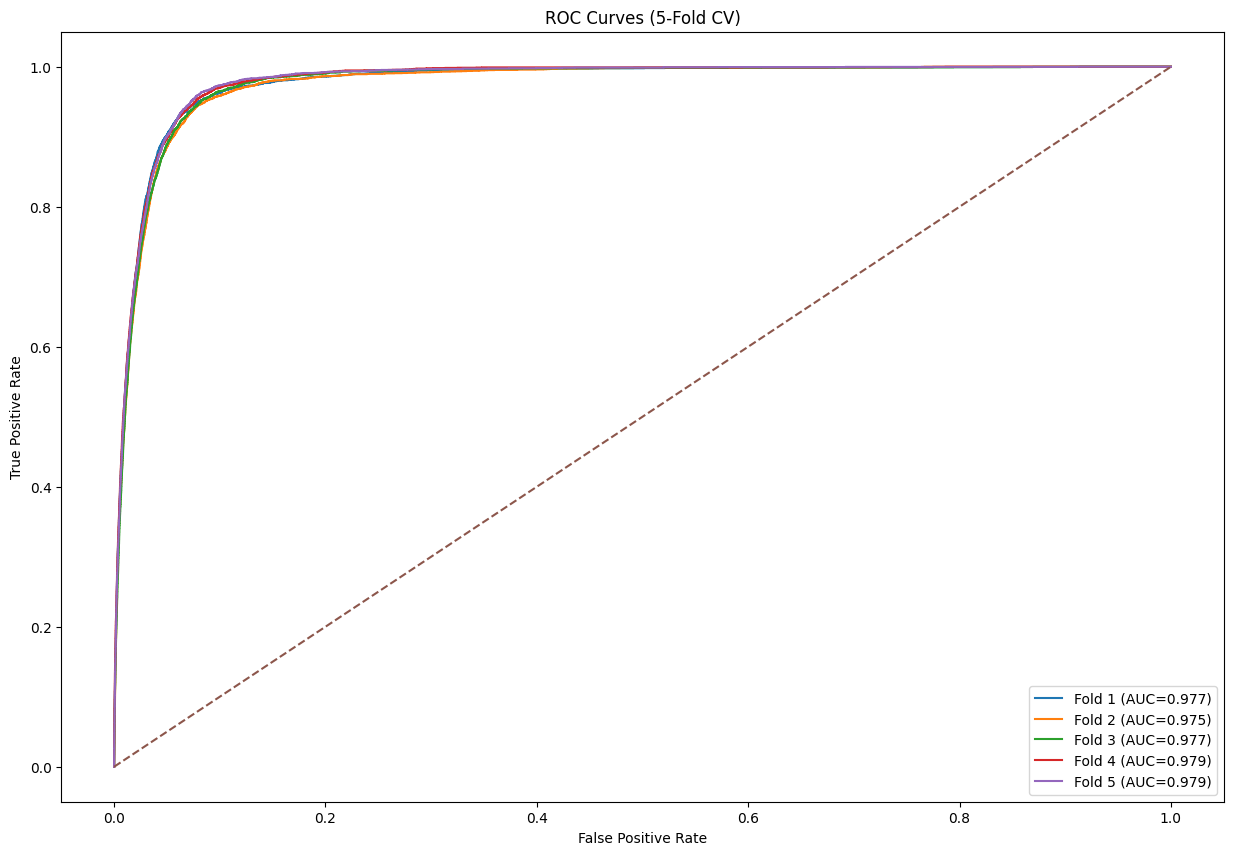

In [17]:
# ---- ROC CURVES ----
plt.figure(figsize=(15,10))
for i, (fpr, tpr, auc) in enumerate(roc_data, 1):
    plt.plot(fpr, tpr, label=f"Fold {i} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (5-Fold CV)")
plt.legend()
plt.show()

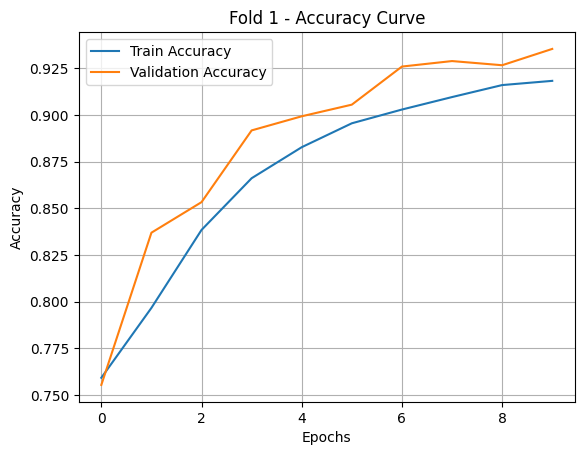

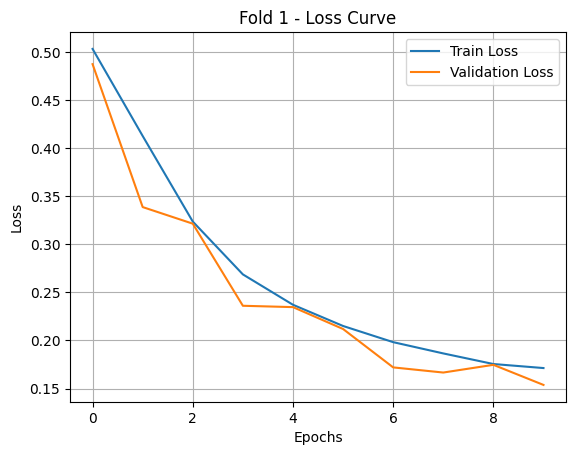

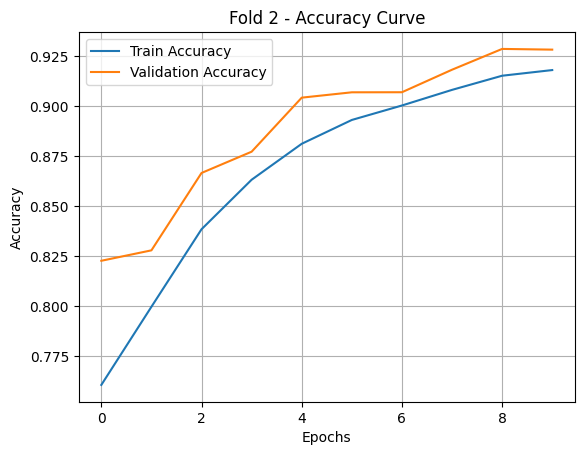

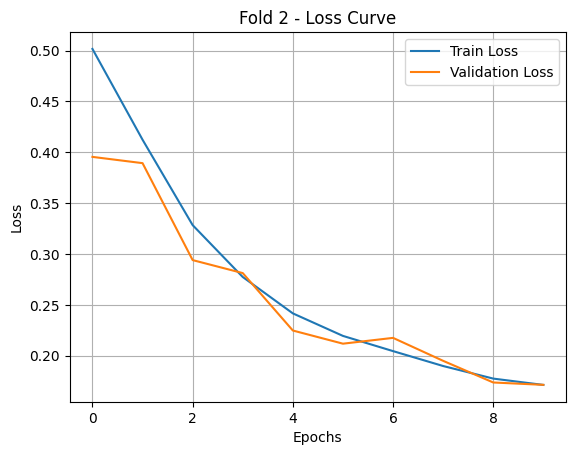

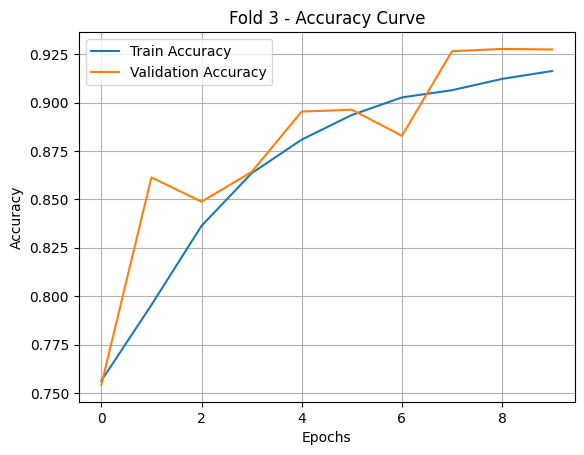

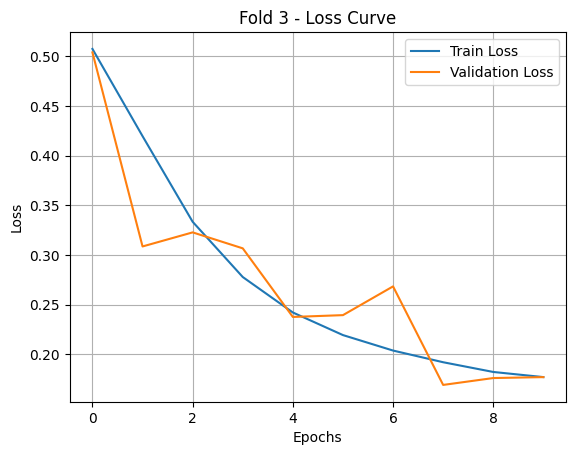

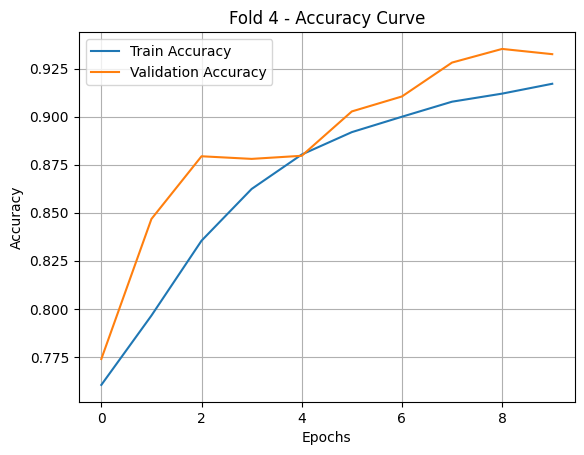

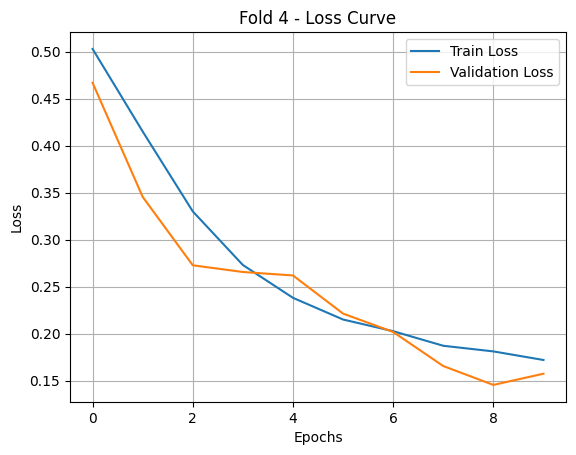

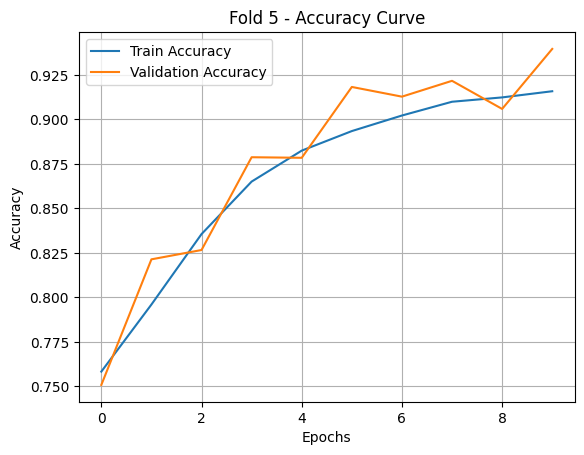

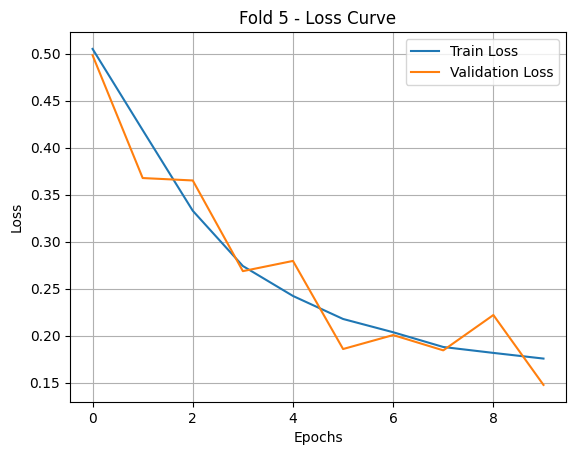

In [18]:
# ==========================
# PER-FOLD TRAINING CURVES
# ==========================
for i, history in enumerate(fold_histories, 1):

    # ----- ACCURACY CURVE -----
    plt.figure()
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"Fold {i} - Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----- LOSS CURVE -----
    plt.figure()
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Fold {i} - Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


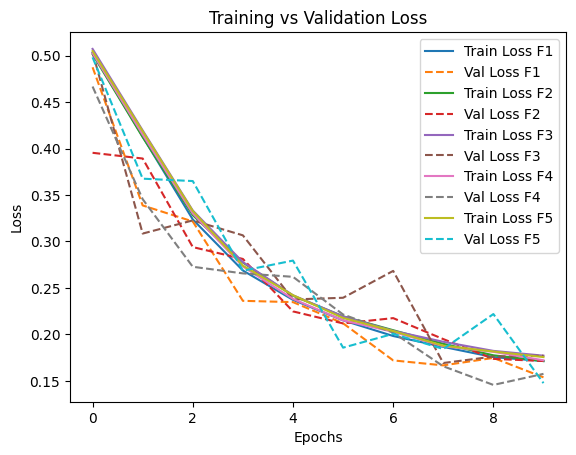

In [16]:
plt.figure()
for i, h in enumerate(fold_histories, 1):
    plt.plot(h.history["loss"], label=f"Train Loss F{i}")
    plt.plot(h.history["val_loss"], linestyle="--", label=f"Val Loss F{i}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()